In [23]:
import os
from dotenv import load_dotenv
from langgraph.graph import StateGraph,START,END
from langchain_groq import ChatGroq
from typing import TypedDict, List, Literal

load_dotenv()

True

In [24]:
model = ChatGroq(model_name = os.getenv('GROQ_MODEL'),
                 api_key= os.getenv('GROQ_API_KEY'))

In [25]:
from operator import add

class BlogState(TypedDict):
  
    blog_title : str
    blog_outline  : str
    blog_content :  str
    blog_score : float
    blog_number : int
    blog_max_number : int
    blog_list : List[str]

In [26]:
def generate_outline(state : BlogState) -> BlogState:
    
    title = state['blog_title']

    prompt = f'Generate a blog outline for the title {title}'

    answer = model.invoke(prompt).content

    state['blog_outline'] = answer

    state['blog_number'] += 1

    return state

In [27]:
def generate_content(state : BlogState) -> BlogState:
    
    title = state['blog_title']

    outline = state['blog_outline']

    prompt = f'Generate a blog based on the title {title} and outline {outline}'

    answer = model.invoke(prompt).content

    state['blog_content'] = answer

    return state

In [28]:
def generate_score(state : BlogState) -> BlogState:
    
    title = state['blog_title']

    outline = state['blog_outline']

    content =  state['blog_content']

    prompt = f'Assign a score(just the number) between 0-10(include 1 decimal point) for the blog with Title -  {title} \n  Outline - {outline} \n Content - {content}'

    score = model.invoke(prompt).content

    state['blog_score'] = round(float(score),1)

    return state

In [29]:
def update_list(state: BlogState) -> BlogState:
    state['blog_list'].append(
        f"#########Title######### - {state['blog_title']}\n#########Outline#########\n{state['blog_outline']}\n"
        f"#########Content#########\n{state['blog_content']}\n#########Score(0-10)######### - {state['blog_score']}"
    )
    return state

In [30]:
def routing_fn(state: BlogState) -> Literal['generate_outline','__end__']:
    
    current_blog_number =  state['blog_number']
    max_blog_number = state['blog_max_number']
    
    if current_blog_number < max_blog_number:
        return 'generate_outline'
    else:
        return '__end__'

In [31]:
graph = StateGraph(BlogState)


graph.add_node('generate_outline',generate_outline)
graph.add_node('generate_content',generate_content)
graph.add_node('generate_score',generate_score)
graph.add_node('update_list',update_list)

graph.add_edge(START,'generate_outline')
graph.add_edge('generate_outline','generate_content')
graph.add_edge('generate_content','generate_score')
graph.add_edge('generate_score','update_list')
graph.add_conditional_edges(
    source = 'update_list',
    path = routing_fn )

workflow = graph.compile()

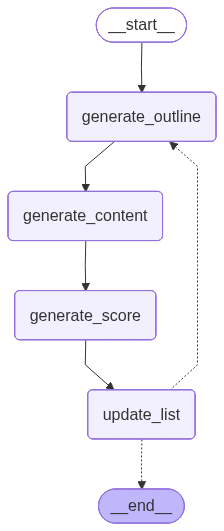

In [32]:
from IPython.display import Image

Image(workflow.get_graph().draw_mermaid_png())

In [33]:
initial_state = {
    'blog_title': 'AI vs Humanity - The Last WAR on earth',
    'blog_number': 0,
    'blog_max_number' : 1,
    'blog_outline': '',
    'blog_content': '',
    'blog_score': '',
    'blog_list': []
}

final_state = workflow.invoke(initial_state)

for blog in final_state['blog_list']:
    print(blog)

#########Title######### - AI vs Humanity - The Last WAR on earth
#########Outline#########
## Blog Outline  
**Title:** *AI vs Humanity – The Last WAR on Earth*  

| # | Section | Sub‑Headings | Key Points / Questions | Suggested Tone |
|---|---------|--------------|------------------------|----------------|
| 1 | **Hook & Thesis** | • The “Last War” myth<br>• Why the AI‑human clash feels inevitable | • “What if the most powerful tool humanity ever created turns against us?”<br>• Set the stakes: survival, identity, ethics | Engaging, slightly ominous |
| 2 | **Historical Precedents** | • Human vs Machine: The Industrial Revolution<br>• Cold War & the arms race | • How tech has reshaped warfare (drones, cyber, nuclear)<br>• Lessons learned about escalation | Reflective, analytical |
| 3 | **The Rise of AI** | • Milestones: Turing → AlphaGo → GPT‑4 → AGI speculation<br>• Capabilities that matter: perception, reasoning, self‑improvement | • What makes AI “dangerous” (speed, opacity, auton